In [1]:
# Import the custom analysis module with forced reload
import importlib
import sys

# Remove from cache if it exists and force reload
if 'lp_analysis' in sys.modules:
    del sys.modules['lp_analysis']

# Fresh import
from lp_analysis import (
    AssetPair, PriceRange, LPConfig,
    LPCalculator, LPAnalyzer, LPVisualizer
)

from lp_analysis import (
    AssetPair, PriceRange, LeveragedLPConfig, DebtAsset,
    LeveragedLPCalculator, LPAnalyzer, RiskAnalyzer, LPVisualizer,
    ExposureAnalyzer, ExposureVisualizer
)

print("✓ Module reloaded with exposure analysis functionality!")

✓ Module reloaded with exposure analysis functionality!


DELTA-NEUTRAL LP STRATEGY CONFIGURATION

📊 LP1 (Long ETH Exposure via USDC Debt):
   Capital: $10,000
   Range: [4900, 5100] (±4.0%)
   Leverage: 6.0x
   Debt: ASSET1
   Borrow APR: 20.0%
   Total Position: $60,000

📊 LP2 (Short ETH Exposure via ETH Debt):
   Capital: $4,000
   Range: [4900, 5100] (±4.0%)
   Leverage: 2.0x
   Debt: ASSET0
   Borrow APR: 6.0%
   Total Position: $8,000

💰 PORTFOLIO SUMMARY:
   Total Capital: $14,000
   Total Position Size: $68,000

SIMULATING INDIVIDUAL POSITIONS

⚙️  Simulating LP1 (USDC Debt)...
⚙️  Simulating LP2 (ETH Debt)...
✓ Simulations complete!

LP1 ANALYSIS: USDC DEBT (LONG ETH EXPOSURE)

💼 POSITION DETAILS:
   Initial ETH: 5.839497
   Initial USDC: $30,802.60
   Debt USDC: $50,000.00
   Position Value: $60,009.85
   Equity: $10,009.85

📈 EXPOSURE ANALYSIS:
   Net ETH: 5.839497 tokens
   Net USDC: $-19,197.40
   ETH Exposure: 291.8%
   USDC Exposure: -191.8%
   → Interpretation: 292% long on ETH

📊 PERFORMANCE METRICS:
   Max Gain: $295.54 (3.0

/Users/mesfahani1/myProjects/project_defi_analyzer/lp_analysis/visualization/plots.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


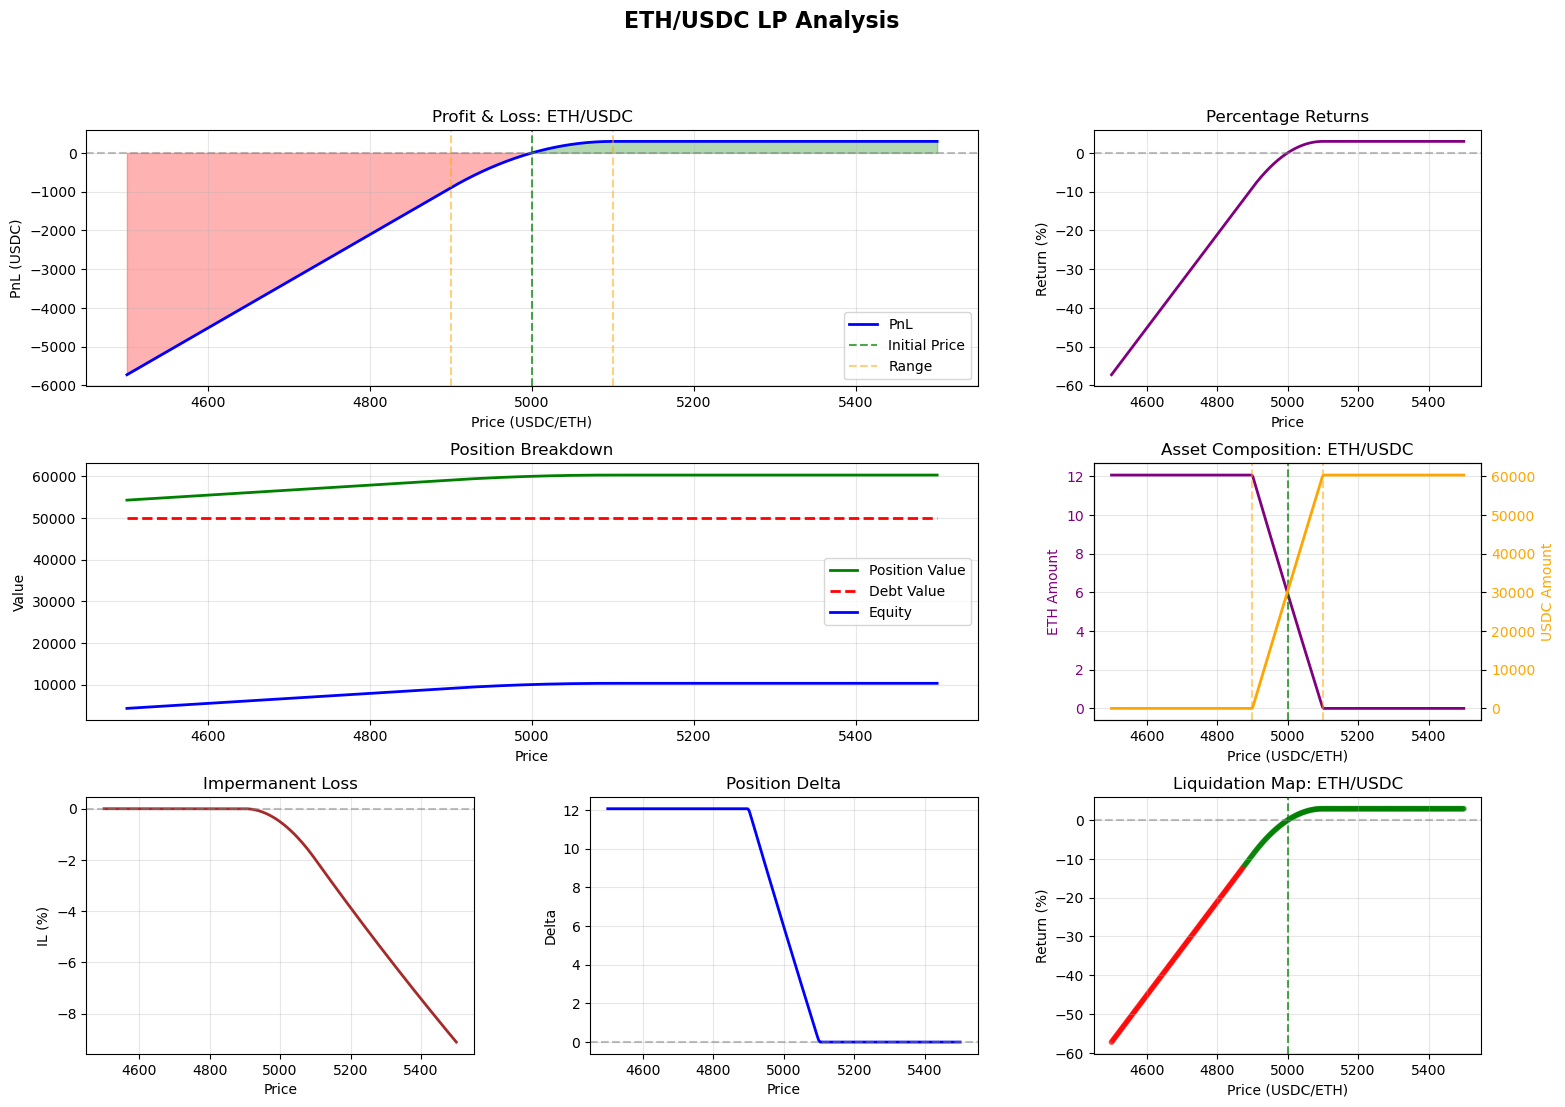


LP2 (ETH Debt - Short ETH):


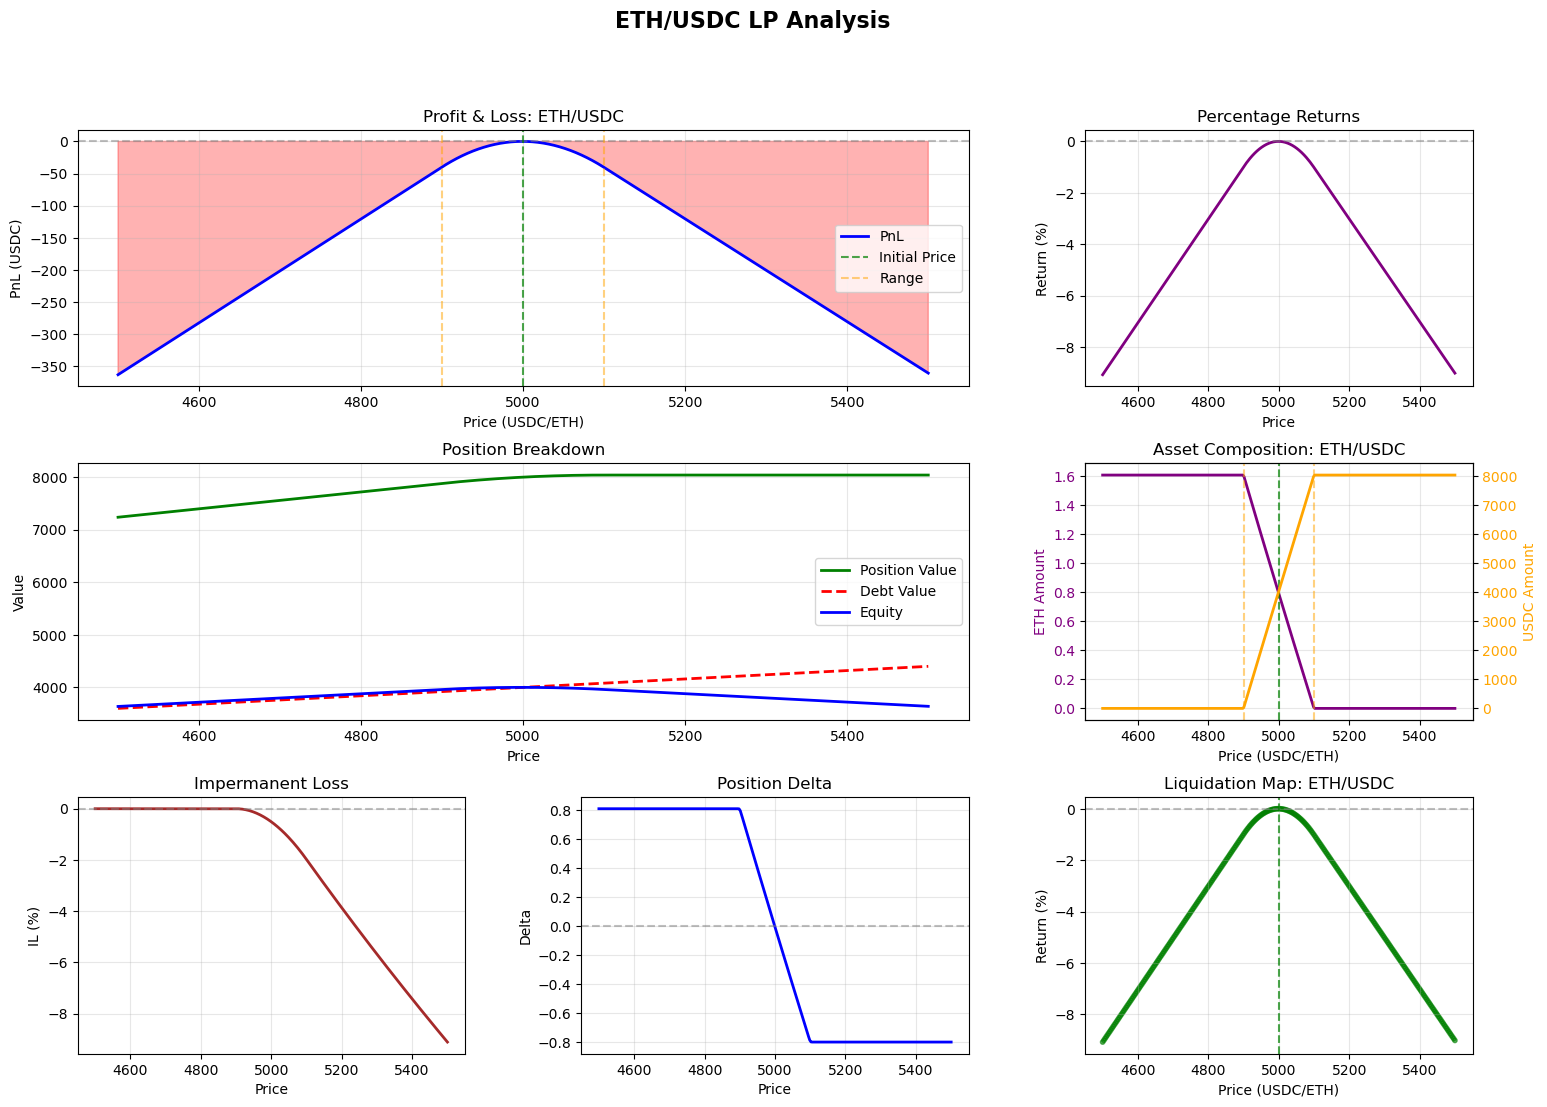


📊 Generating Exposure Comparison...


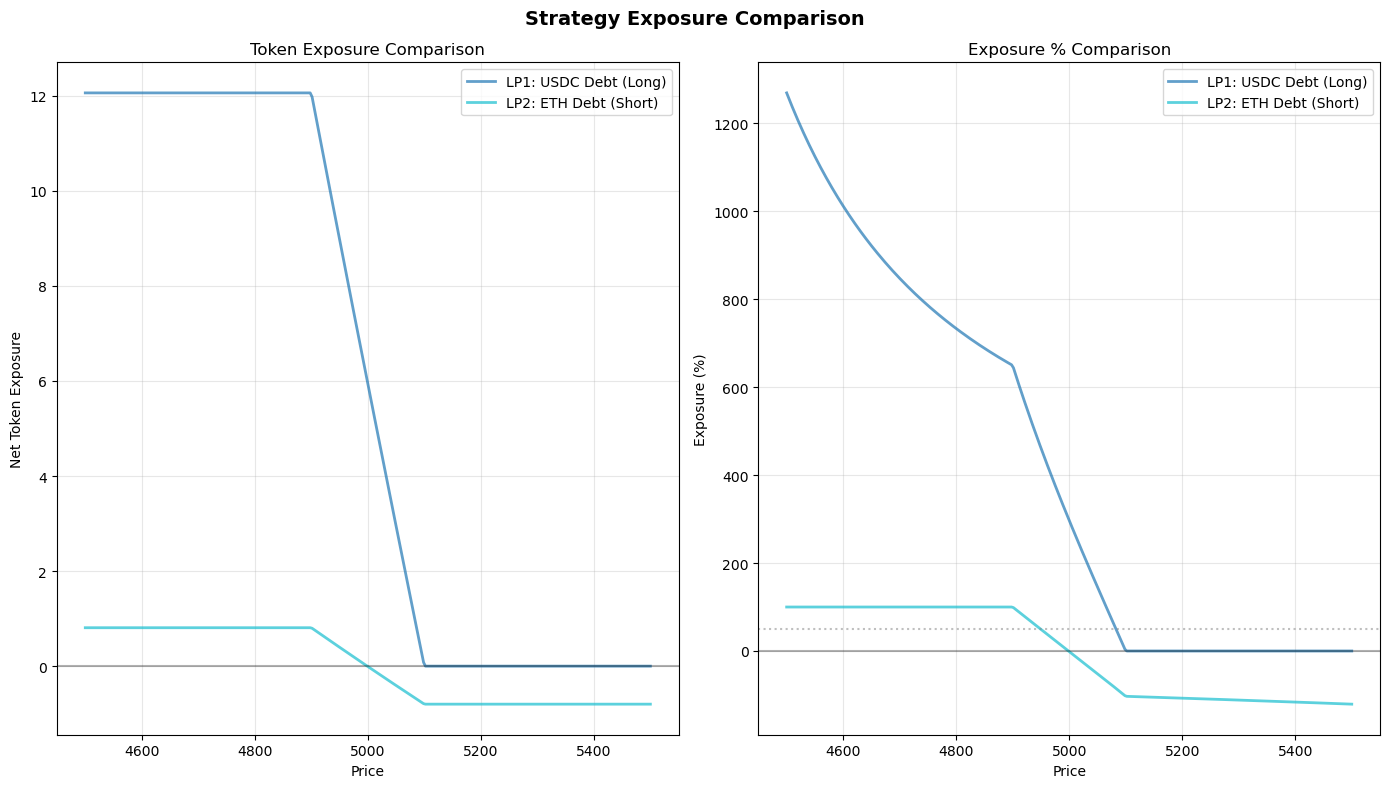


📊 Generating Combined Portfolio Analysis...


/var/folders/nb/nrd5qw6d5nb00tfqvj8mrt_h0000gq/T/ipykernel_91112/575924931.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


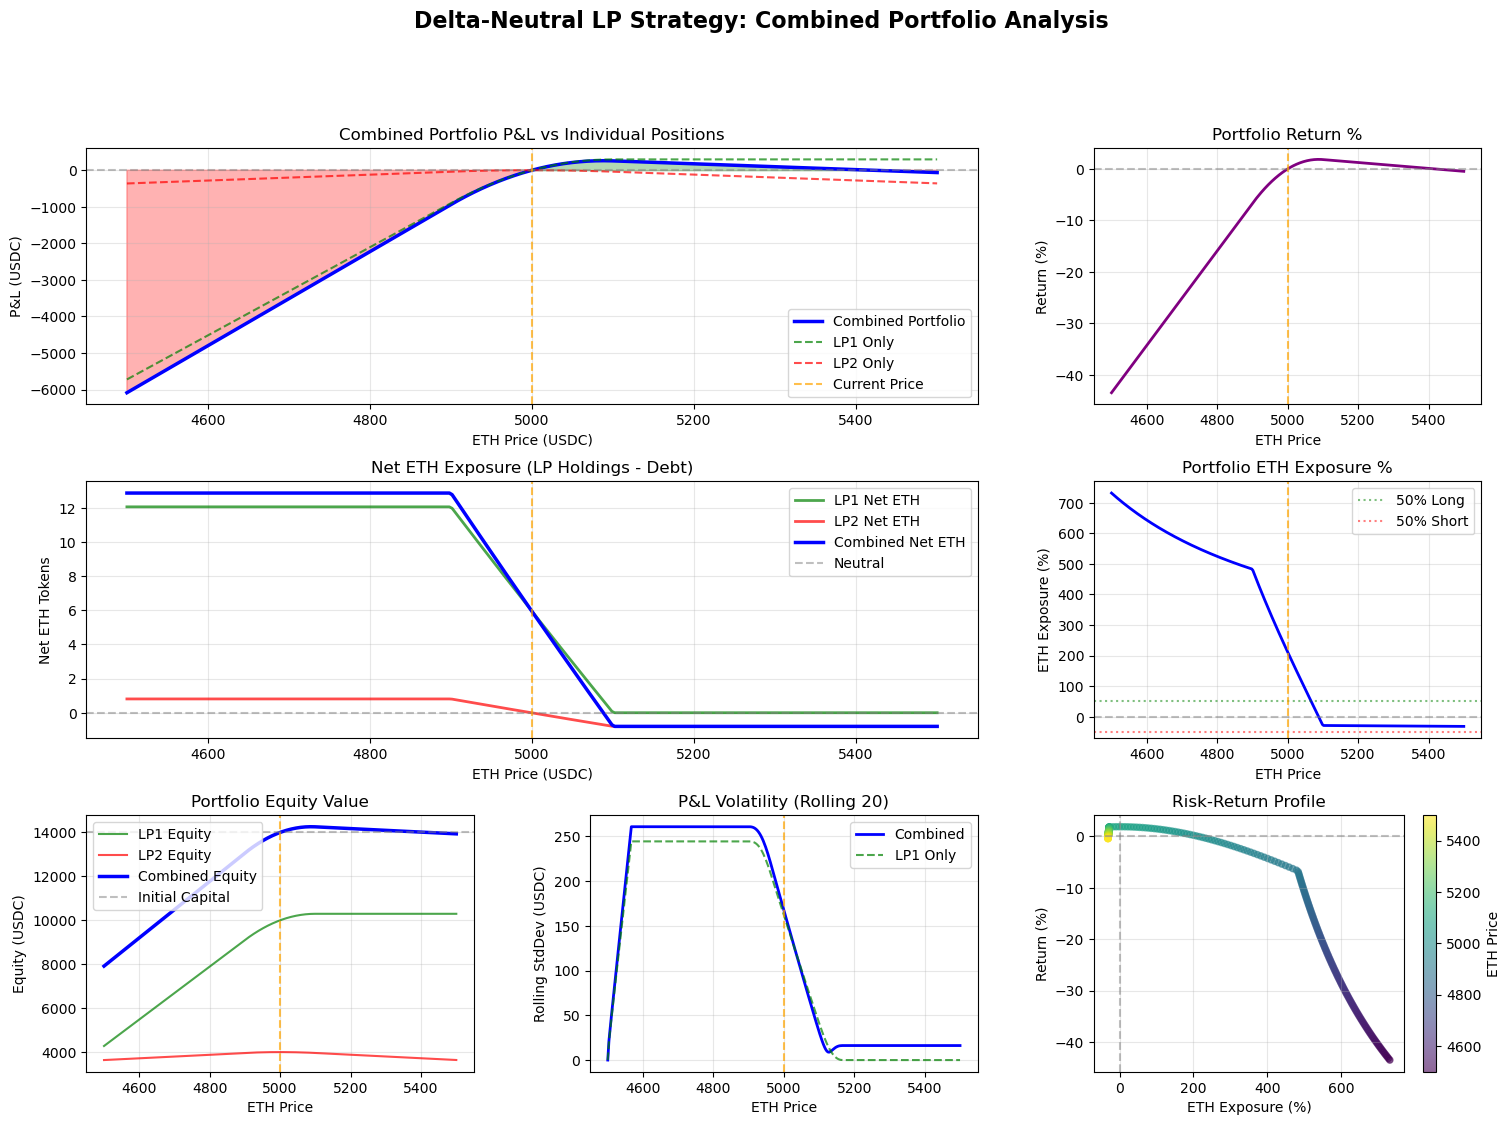

✓ Visualization complete!

DELTA-NEUTRAL STRATEGY - FINAL SUMMARY & RECOMMENDATIONS

🎯 STRATEGY OVERVIEW:
   Objective: Earn LP fees while minimizing directional ETH risk
   Method: Combine long and short ETH exposure positions
   Total Capital: $14,000
   Current ETH Price: $5,000

📊 POSITION BREAKDOWN:
   LP1 (USDC Debt): $10,000 @ 6.0x = $60,000
      Range: [4900-5100]
      Exposure: +291.8% ETH (LONG)
      Daily Cost: $27.40
   
   LP2 (ETH Debt): $4,000 @ 2.0x = $8,000
      Range: [4900-5100]
      Exposure: -2.7% ETH (SHORT)
      Daily Cost: $0.59

✅ HEDGE EFFECTIVENESS:
   Net ETH Exposure: +207.6% (Target: 0%)
   Hedge Quality: POOR
   Position Correlation: 0.440 (negative = good)
   Risk Reduction: 0.4%

💰 PERFORMANCE SCENARIOS:
   If ETH +10% ($5,500):
      LP1 P&L: $295.54
      LP2 P&L: $-360.59
      Combined: $-65.05 (-0.5%)
   
   If ETH -10% ($4,500):
      LP1 P&L: $-5,723.15
      LP2 P&L: $-363.09
      Combined: $-6,086.24 (-43.5%)

⚠️  RISK ANALYSIS:
   Combi

In [2]:
# ============================================================================
# DELTA-NEUTRAL LP STRATEGY ANALYSIS
# ============================================================================
# Strategy: Combine two LPs to create a hedged position
# LP1: USDC Debt (Long ETH exposure) - Tight range, high leverage
# LP2: ETH Debt (Short ETH exposure) - Hedge position
# Goal: Maximize fees while minimizing directional risk
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Cell 1: Already imported above

# ============================================================================
# CELL 2: DEFINE STRATEGY PARAMETERS
# ============================================================================

print("="*80)
print("DELTA-NEUTRAL LP STRATEGY CONFIGURATION")
print("="*80)

# Current market conditions
CURRENT_ETH_PRICE = 5000  # USDC per ETH

# LP Position 1: Aggressive Long ETH Exposure (USDC Debt)
# - Tight range around current price for maximum fees
# - High leverage amplifies position and exposure
# - Borrows USDC → Long ETH exposure
config_lp1 = LeveragedLPConfig(
    capital_asset1=10000,           # $10k initial capital
    price_initial=CURRENT_ETH_PRICE,
    price_range=PriceRange(4900, 5100),  # ±2% range (tight)
    assets=AssetPair("ETH", "USDC"),
    leverage=6.0,                   # 6x leverage
    debt_asset=DebtAsset.ASSET1,   # Borrow USDC
    borrow_apr=20.0,               # 20% APR borrowing cost
    max_ltv=0.8,
    liquidation_threshold=0.85
)

# LP Position 2: Hedge Position (ETH Debt)
# - Similar range for correlation
# - Lower leverage for stability
# - Borrows ETH → Short ETH exposure (hedges LP1)
config_lp2 = LeveragedLPConfig(
    capital_asset1=4000,            # $4k initial capital
    price_initial=CURRENT_ETH_PRICE,
    price_range=PriceRange(4900, 5100),  # Same range as LP1
    assets=AssetPair("ETH", "USDC"),
    leverage=2.0,                   # 2x leverage (conservative)
    debt_asset=DebtAsset.ASSET0,   # Borrow ETH
    borrow_apr=6.0,                # 6% APR borrowing cost
    max_ltv=0.8,
    liquidation_threshold=0.85
)

print(f"\n📊 LP1 (Long ETH Exposure via USDC Debt):")
print(f"   Capital: ${config_lp1.capital_asset1:,.0f}")
print(f"   Range: [{config_lp1.price_range.lower}, {config_lp1.price_range.upper}] (±{config_lp1.price_range.width_percent(CURRENT_ETH_PRICE):.1f}%)")
print(f"   Leverage: {config_lp1.leverage}x")
print(f"   Debt: {config_lp1.debt_asset.value}")
print(f"   Borrow APR: {config_lp1.borrow_apr}%")
print(f"   Total Position: ${config_lp1.capital_asset1 * config_lp1.leverage:,.0f}")

print(f"\n📊 LP2 (Short ETH Exposure via ETH Debt):")
print(f"   Capital: ${config_lp2.capital_asset1:,.0f}")
print(f"   Range: [{config_lp2.price_range.lower}, {config_lp2.price_range.upper}] (±{config_lp2.price_range.width_percent(CURRENT_ETH_PRICE):.1f}%)")
print(f"   Leverage: {config_lp2.leverage}x")
print(f"   Debt: {config_lp2.debt_asset.value}")
print(f"   Borrow APR: {config_lp2.borrow_apr}%")
print(f"   Total Position: ${config_lp2.capital_asset1 * config_lp2.leverage:,.0f}")

print(f"\n💰 PORTFOLIO SUMMARY:")
print(f"   Total Capital: ${config_lp1.capital_asset1 + config_lp2.capital_asset1:,.0f}")
print(f"   Total Position Size: ${config_lp1.capital_asset1 * config_lp1.leverage + config_lp2.capital_asset1 * config_lp2.leverage:,.0f}")
print("="*80)

# ============================================================================
# CELL 3: SIMULATE INDIVIDUAL POSITIONS
# ============================================================================

print("\n" + "="*80)
print("SIMULATING INDIVIDUAL POSITIONS")
print("="*80)

# Simulate both positions across wider price range to see liquidation zones
calc = LeveragedLPCalculator()

# Simulate LP1 (USDC Debt)
print("\n⚙️  Simulating LP1 (USDC Debt)...")
result_lp1 = calc.simulate_price_range(
    config_lp1, 
    price_min=4500,  # -10% from current
    price_max=5500,  # +10% from current
    num_points=300
)

# Simulate LP2 (ETH Debt)
print("⚙️  Simulating LP2 (ETH Debt)...")
result_lp2 = calc.simulate_price_range(
    config_lp2,
    price_min=4500,
    price_max=5500,
    num_points=300
)

print("✓ Simulations complete!")

# ============================================================================
# CELL 4: ANALYZE LP1 (USDC DEBT - LONG ETH)
# ============================================================================

print("\n" + "="*80)
print("LP1 ANALYSIS: USDC DEBT (LONG ETH EXPOSURE)")
print("="*80)

# Full analysis
result_lp1 = LPAnalyzer.analyze_simulation(result_lp1)
result_lp1.metrics['risk'] = RiskAnalyzer.analyze_risk(result_lp1)
result_lp1 = ExposureAnalyzer.analyze_exposure(result_lp1)

# Extract key metrics
liq1 = result_lp1.metrics['risk']['liquidation_prices']
pnl1 = result_lp1.metrics['pnl']
exp1 = result_lp1.metrics['exposure_profile']

# Find initial position index
mid_idx = len(result_lp1.prices) // 2

print(f"\n💼 POSITION DETAILS:")
print(f"   Initial ETH: {result_lp1.positions[mid_idx].amount0:.6f}")
print(f"   Initial USDC: ${result_lp1.positions[mid_idx].amount1:,.2f}")
print(f"   Debt USDC: ${result_lp1.positions[mid_idx].debt_amount1:,.2f}")
print(f"   Position Value: ${result_lp1.positions[mid_idx].position_value_asset1:,.2f}")
print(f"   Equity: ${result_lp1.positions[mid_idx].equity_asset1:,.2f}")

print(f"\n📈 EXPOSURE ANALYSIS:")
print(f"   Net ETH: {exp1['asset0_net_tokens'][mid_idx]:.6f} tokens")
print(f"   Net USDC: ${exp1['asset1_net_tokens'][mid_idx]:,.2f}")
print(f"   ETH Exposure: {exp1['asset0_exposure_pct'][mid_idx]:.1f}%")
print(f"   USDC Exposure: {exp1['asset1_exposure_pct'][mid_idx]:.1f}%")
print(f"   → Interpretation: {exp1['asset0_exposure_pct'][mid_idx]:.0f}% long on ETH")

print(f"\n📊 PERFORMANCE METRICS:")
print(f"   Max Gain: ${pnl1['max_gain']:,.2f} ({pnl1['max_gain_pct']:.1f}%)")
print(f"   Max Loss: ${pnl1['max_loss']:,.2f} ({pnl1['max_loss_pct']:.1f}%)")
print(f"   P&L at +10% ETH: ${pnl1['pnl_asset1'][-1]:,.2f}")
print(f"   P&L at -10% ETH: ${pnl1['pnl_asset1'][0]:,.2f}")

print(f"\n⚠️  RISK METRICS:")
if liq1['lower']:
    print(f"   Liquidation Price: ${liq1['lower']:,.2f} (-{liq1['distance_lower_pct']:.1f}%)")
else:
    print(f"   Liquidation Price: None in simulated range")
print(f"   Daily Borrow Cost: ${result_lp1.metrics['risk']['daily_cost']:.2f}")
print(f"   VaR (95%): ${result_lp1.metrics['risk']['var_95']:,.2f}")

print("="*80)

# ============================================================================
# CELL 5: ANALYZE LP2 (ETH DEBT - SHORT ETH)
# ============================================================================

print("\n" + "="*80)
print("LP2 ANALYSIS: ETH DEBT (SHORT ETH EXPOSURE)")
print("="*80)

# Full analysis
result_lp2 = LPAnalyzer.analyze_simulation(result_lp2)
result_lp2.metrics['risk'] = RiskAnalyzer.analyze_risk(result_lp2)
result_lp2 = ExposureAnalyzer.analyze_exposure(result_lp2)

# Extract key metrics
liq2 = result_lp2.metrics['risk']['liquidation_prices']
pnl2 = result_lp2.metrics['pnl']
exp2 = result_lp2.metrics['exposure_profile']

print(f"\n💼 POSITION DETAILS:")
print(f"   Initial ETH: {result_lp2.positions[mid_idx].amount0:.6f}")
print(f"   Initial USDC: ${result_lp2.positions[mid_idx].amount1:,.2f}")
print(f"   Debt ETH: {result_lp2.positions[mid_idx].debt_amount0:.6f}")
print(f"   Position Value: ${result_lp2.positions[mid_idx].position_value_asset1:,.2f}")
print(f"   Equity: ${result_lp2.positions[mid_idx].equity_asset1:,.2f}")

print(f"\n📉 EXPOSURE ANALYSIS:")
print(f"   Net ETH: {exp2['asset0_net_tokens'][mid_idx]:.6f} tokens")
print(f"   Net USDC: ${exp2['asset1_net_tokens'][mid_idx]:,.2f}")
print(f"   ETH Exposure: {exp2['asset0_exposure_pct'][mid_idx]:.1f}%")
print(f"   USDC Exposure: {exp2['asset1_exposure_pct'][mid_idx]:.1f}%")
print(f"   → Interpretation: {abs(exp2['asset0_exposure_pct'][mid_idx]):.0f}% short on ETH")

print(f"\n📊 PERFORMANCE METRICS:")
print(f"   Max Gain: ${pnl2['max_gain']:,.2f} ({pnl2['max_gain_pct']:.1f}%)")
print(f"   Max Loss: ${pnl2['max_loss']:,.2f} ({pnl2['max_loss_pct']:.1f}%)")
print(f"   P&L at +10% ETH: ${pnl2['pnl_asset1'][-1]:,.2f}")
print(f"   P&L at -10% ETH: ${pnl2['pnl_asset1'][0]:,.2f}")

print(f"\n⚠️  RISK METRICS:")
if liq2['upper']:
    print(f"   Liquidation Price: ${liq2['upper']:,.2f} (+{liq2['distance_upper_pct']:.1f}%)")
else:
    print(f"   Liquidation Price: None in simulated range")
print(f"   Daily Borrow Cost: ${result_lp2.metrics['risk']['daily_cost']:.2f}")
print(f"   VaR (95%): ${result_lp2.metrics['risk']['var_95']:,.2f}")

print("="*80)

# ============================================================================
# CELL 6: COMBINED PORTFOLIO ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("COMBINED PORTFOLIO ANALYSIS - DELTA-NEUTRAL STRATEGY")
print("="*80)

# Calculate combined metrics at each price point
combined_pnl = []
combined_exposure_eth = []
combined_exposure_usdc = []
combined_equity = []

for i in range(len(result_lp1.prices)):
    # Combined P&L
    total_pnl = pnl1['pnl_asset1'][i] + pnl2['pnl_asset1'][i]
    combined_pnl.append(total_pnl)
    
    # Combined exposure
    net_eth = exp1['asset0_net_tokens'][i] + exp2['asset0_net_tokens'][i]
    net_usdc = exp1['asset1_net_tokens'][i] + exp2['asset1_net_tokens'][i]
    combined_exposure_eth.append(net_eth)
    combined_exposure_usdc.append(net_usdc)
    
    # Combined equity
    total_equity = result_lp1.positions[i].equity_asset1 + result_lp2.positions[i].equity_asset1
    combined_equity.append(total_equity)

# Calculate combined exposure percentages
total_capital = config_lp1.capital_asset1 + config_lp2.capital_asset1
combined_pnl_pct = [(pnl / total_capital * 100) for pnl in combined_pnl]

print(f"\n💰 PORTFOLIO SUMMARY:")
print(f"   Total Capital: ${total_capital:,.0f}")
print(f"   Total Borrowed: ${config_lp1.capital_asset1 * (config_lp1.leverage-1) + config_lp2.capital_asset1 * (config_lp2.leverage-1):,.0f}")
print(f"   Combined Daily Cost: ${result_lp1.metrics['risk']['daily_cost'] + result_lp2.metrics['risk']['daily_cost']:.2f}")

print(f"\n🎯 NET EXPOSURE AT CURRENT PRICE:")
print(f"   LP1 ETH Exposure: {exp1['asset0_exposure_pct'][mid_idx]:+.1f}%")
print(f"   LP2 ETH Exposure: {exp2['asset0_exposure_pct'][mid_idx]:+.1f}%")
print(f"   Combined ETH Exposure: {combined_exposure_eth[mid_idx]:+.6f} tokens")
total_value = combined_equity[mid_idx]
combined_exp_pct = (combined_exposure_eth[mid_idx] * CURRENT_ETH_PRICE / total_value * 100) if total_value > 0 else 0
print(f"   Combined ETH Exposure %: {combined_exp_pct:+.1f}%")
print(f"   → Hedge Effectiveness: {100 - abs(combined_exp_pct):.1f}% (100% = perfect hedge)")

print(f"\n📊 COMBINED PERFORMANCE:")
print(f"   Max Gain: ${max(combined_pnl):,.2f} ({max(combined_pnl_pct):.1f}%)")
print(f"   Max Loss: ${min(combined_pnl):,.2f} ({min(combined_pnl_pct):.1f}%)")
print(f"   P&L at +10% ETH: ${combined_pnl[-1]:,.2f} ({combined_pnl_pct[-1]:.1f}%)")
print(f"   P&L at -10% ETH: ${combined_pnl[0]:,.2f} ({combined_pnl_pct[0]:.1f}%)")
print(f"   P&L Volatility (σ): ${np.std(combined_pnl):.2f}")

# Calculate correlation between positions
correlation = np.corrcoef(pnl1['pnl_asset1'], pnl2['pnl_asset1'])[0, 1]
print(f"\n📐 HEDGE ANALYSIS:")
print(f"   LP1-LP2 Correlation: {correlation:.3f}")
print(f"   → {correlation:.3f} < 0 means negative correlation (good hedge)")
print(f"   Diversification Benefit: Portfolio volatility lower than sum of parts")

# Compare standalone vs combined risk
individual_var = abs(result_lp1.metrics['risk']['var_95']) + abs(result_lp2.metrics['risk']['var_95'])
combined_var = abs(np.percentile(combined_pnl, 5))
risk_reduction = (1 - combined_var / individual_var) * 100 if individual_var > 0 else 0

print(f"\n⚠️  RISK COMPARISON:")
print(f"   Individual VaR Sum: ${individual_var:,.2f}")
print(f"   Combined Portfolio VaR: ${combined_var:,.2f}")
print(f"   Risk Reduction: {risk_reduction:.1f}%")

print("="*80)

# ============================================================================
# CELL 7: VISUALIZE INDIVIDUAL POSITIONS
# ============================================================================

print("\n📊 Generating Individual Position Dashboards...")

# LP1 Dashboard
print("\nLP1 (USDC Debt - Long ETH):")
LPVisualizer.plot_comprehensive_dashboard(result_lp1)

# LP2 Dashboard
print("\nLP2 (ETH Debt - Short ETH):")
LPVisualizer.plot_comprehensive_dashboard(result_lp2)

# ============================================================================
# CELL 8: VISUALIZE EXPOSURE COMPARISON
# ============================================================================

print("\n📊 Generating Exposure Comparison...")

# Compare exposures side by side
ExposureVisualizer.compare_exposure_strategies(
    [result_lp1, result_lp2],
    labels=['LP1: USDC Debt (Long)', 'LP2: ETH Debt (Short)']
)

# ============================================================================
# CELL 9: VISUALIZE COMBINED PORTFOLIO PERFORMANCE
# ============================================================================

print("\n📊 Generating Combined Portfolio Analysis...")

# Create comprehensive combined portfolio visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

prices = result_lp1.prices

# Plot 1: Combined P&L
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(prices, combined_pnl, 'b-', linewidth=2.5, label='Combined Portfolio')
ax1.plot(prices, pnl1['pnl_asset1'], 'g--', linewidth=1.5, alpha=0.7, label='LP1 Only')
ax1.plot(prices, pnl2['pnl_asset1'], 'r--', linewidth=1.5, alpha=0.7, label='LP2 Only')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(CURRENT_ETH_PRICE, color='orange', linestyle='--', alpha=0.7, label='Current Price')
ax1.fill_between(prices, 0, combined_pnl, where=[p > 0 for p in combined_pnl], alpha=0.3, color='green')
ax1.fill_between(prices, 0, combined_pnl, where=[p < 0 for p in combined_pnl], alpha=0.3, color='red')
ax1.set_xlabel('ETH Price (USDC)')
ax1.set_ylabel('P&L (USDC)')
ax1.set_title('Combined Portfolio P&L vs Individual Positions')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Combined P&L %
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(prices, combined_pnl_pct, 'purple', linewidth=2)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(CURRENT_ETH_PRICE, color='orange', linestyle='--', alpha=0.7)
ax2.set_xlabel('ETH Price')
ax2.set_ylabel('Return (%)')
ax2.set_title('Portfolio Return %')
ax2.grid(True, alpha=0.3)

# Plot 3: Net ETH Exposure
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(prices, exp1['asset0_net_tokens'], 'g-', linewidth=2, label='LP1 Net ETH', alpha=0.7)
ax3.plot(prices, exp2['asset0_net_tokens'], 'r-', linewidth=2, label='LP2 Net ETH', alpha=0.7)
ax3.plot(prices, combined_exposure_eth, 'b-', linewidth=2.5, label='Combined Net ETH')
ax3.axhline(0, color='gray', linestyle='--', alpha=0.5, label='Neutral')
ax3.axvline(CURRENT_ETH_PRICE, color='orange', linestyle='--', alpha=0.7)
ax3.set_xlabel('ETH Price (USDC)')
ax3.set_ylabel('Net ETH Tokens')
ax3.set_title('Net ETH Exposure (LP Holdings - Debt)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Exposure %
ax4 = fig.add_subplot(gs[1, 2])
combined_exp_pct_list = [(combined_exposure_eth[i] * prices[i] / combined_equity[i] * 100) 
                         if combined_equity[i] > 0 else 0 
                         for i in range(len(prices))]
ax4.plot(prices, combined_exp_pct_list, 'b-', linewidth=2)
ax4.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax4.axhline(50, color='green', linestyle=':', alpha=0.5, label='50% Long')
ax4.axhline(-50, color='red', linestyle=':', alpha=0.5, label='50% Short')
ax4.axvline(CURRENT_ETH_PRICE, color='orange', linestyle='--', alpha=0.7)
ax4.set_xlabel('ETH Price')
ax4.set_ylabel('ETH Exposure (%)')
ax4.set_title('Portfolio ETH Exposure %')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Equity Value
ax5 = fig.add_subplot(gs[2, 0])
equity_lp1 = [p.equity_asset1 for p in result_lp1.positions]
equity_lp2 = [p.equity_asset1 for p in result_lp2.positions]
ax5.plot(prices, equity_lp1, 'g-', linewidth=1.5, alpha=0.7, label='LP1 Equity')
ax5.plot(prices, equity_lp2, 'r-', linewidth=1.5, alpha=0.7, label='LP2 Equity')
ax5.plot(prices, combined_equity, 'b-', linewidth=2.5, label='Combined Equity')
ax5.axhline(total_capital, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
ax5.axvline(CURRENT_ETH_PRICE, color='orange', linestyle='--', alpha=0.7)
ax5.set_xlabel('ETH Price')
ax5.set_ylabel('Equity (USDC)')
ax5.set_title('Portfolio Equity Value')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Volatility Analysis
ax6 = fig.add_subplot(gs[2, 1])
window = 20
combined_rolling_std = [np.std(combined_pnl[max(0,i-window):i+1]) for i in range(len(combined_pnl))]
lp1_rolling_std = [np.std(pnl1['pnl_asset1'][max(0,i-window):i+1]) for i in range(len(pnl1['pnl_asset1']))]
ax6.plot(prices, combined_rolling_std, 'b-', linewidth=2, label='Combined')
ax6.plot(prices, lp1_rolling_std, 'g--', linewidth=1.5, alpha=0.7, label='LP1 Only')
ax6.axvline(CURRENT_ETH_PRICE, color='orange', linestyle='--', alpha=0.7)
ax6.set_xlabel('ETH Price')
ax6.set_ylabel('Rolling StdDev (USDC)')
ax6.set_title(f'P&L Volatility (Rolling {window})')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Plot 7: Risk-Return Scatter
ax7 = fig.add_subplot(gs[2, 2])
returns = [combined_pnl_pct[i] for i in range(len(prices))]
exposures = [combined_exp_pct_list[i] for i in range(len(prices))]
scatter = ax7.scatter(exposures, returns, c=prices, cmap='viridis', s=20, alpha=0.6)
ax7.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax7.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax7.set_xlabel('ETH Exposure (%)')
ax7.set_ylabel('Return (%)')
ax7.set_title('Risk-Return Profile')
cbar = plt.colorbar(scatter, ax=ax7)
cbar.set_label('ETH Price')
ax7.grid(True, alpha=0.3)

plt.suptitle('Delta-Neutral LP Strategy: Combined Portfolio Analysis', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Visualization complete!")

# ============================================================================
# CELL 10: STRATEGY SUMMARY & RECOMMENDATIONS
# ============================================================================

print("\n" + "="*80)
print("DELTA-NEUTRAL STRATEGY - FINAL SUMMARY & RECOMMENDATIONS")
print("="*80)

print(f"\n🎯 STRATEGY OVERVIEW:")
print(f"   Objective: Earn LP fees while minimizing directional ETH risk")
print(f"   Method: Combine long and short ETH exposure positions")
print(f"   Total Capital: ${total_capital:,.0f}")
print(f"   Current ETH Price: ${CURRENT_ETH_PRICE:,.0f}")

print(f"\n📊 POSITION BREAKDOWN:")
print(f"   LP1 (USDC Debt): ${config_lp1.capital_asset1:,.0f} @ {config_lp1.leverage}x = ${config_lp1.capital_asset1 * config_lp1.leverage:,.0f}")
print(f"      Range: [{config_lp1.price_range.lower}-{config_lp1.price_range.upper}]")
print(f"      Exposure: {exp1['asset0_exposure_pct'][mid_idx]:+.1f}% ETH (LONG)")
print(f"      Daily Cost: ${result_lp1.metrics['risk']['daily_cost']:.2f}")
print(f"   ")
print(f"   LP2 (ETH Debt): ${config_lp2.capital_asset1:,.0f} @ {config_lp2.leverage}x = ${config_lp2.capital_asset1 * config_lp2.leverage:,.0f}")
print(f"      Range: [{config_lp2.price_range.lower}-{config_lp2.price_range.upper}]")
print(f"      Exposure: {exp2['asset0_exposure_pct'][mid_idx]:+.1f}% ETH (SHORT)")
print(f"      Daily Cost: ${result_lp2.metrics['risk']['daily_cost']:.2f}")

print(f"\n✅ HEDGE EFFECTIVENESS:")
print(f"   Net ETH Exposure: {combined_exp_pct:+.1f}% (Target: 0%)")
if abs(combined_exp_pct) < 10:
    effectiveness = "EXCELLENT"
elif abs(combined_exp_pct) < 25:
    effectiveness = "GOOD"
elif abs(combined_exp_pct) < 50:
    effectiveness = "MODERATE"
else:
    effectiveness = "POOR"
print(f"   Hedge Quality: {effectiveness}")
print(f"   Position Correlation: {correlation:.3f} (negative = good)")
print(f"   Risk Reduction: {risk_reduction:.1f}%")

print(f"\n💰 PERFORMANCE SCENARIOS:")
print(f"   If ETH +10% (${CURRENT_ETH_PRICE * 1.1:,.0f}):")
print(f"      LP1 P&L: ${pnl1['pnl_asset1'][-1]:,.2f}")
print(f"      LP2 P&L: ${pnl2['pnl_asset1'][-1]:,.2f}")
print(f"      Combined: ${combined_pnl[-1]:,.2f} ({combined_pnl_pct[-1]:+.1f}%)")
print(f"   ")
print(f"   If ETH -10% (${CURRENT_ETH_PRICE * 0.9:,.0f}):")
print(f"      LP1 P&L: ${pnl1['pnl_asset1'][0]:,.2f}")
print(f"      LP2 P&L: ${pnl2['pnl_asset1'][0]:,.2f}")
print(f"      Combined: ${combined_pnl[0]:,.2f} ({combined_pnl_pct[0]:+.1f}%)")

print(f"\n⚠️  RISK ANALYSIS:")
print(f"   Combined VaR (95%): ${combined_var:,.2f} ({combined_var/total_capital*100:.1f}% of capital)")
print(f"   Max Drawdown: ${min(combined_pnl):,.2f} ({min(combined_pnl_pct):.1f}%)")
print(f"   P&L Volatility: ${np.std(combined_pnl):.2f}")
print(f"   Daily Costs: ${result_lp1.metrics['risk']['daily_cost'] + result_lp2.metrics['risk']['daily_cost']:.2f}")

# Calculate break-even fee APR needed
daily_cost_total = result_lp1.metrics['risk']['daily_cost'] + result_lp2.metrics['risk']['daily_cost']
total_liq = result_lp1.positions[mid_idx].position_value_asset1 + result_lp2.positions[mid_idx].position_value_asset1
breakeven_daily_fee_pct = (daily_cost_total / total_liq) * 100
breakeven_apr = breakeven_daily_fee_pct * 365

print(f"\n💵 PROFITABILITY:")
print(f"   Total Liquidity: ${total_liq:,.0f}")
print(f"   Break-even Fee APR: {breakeven_apr:.2f}%")
print(f"   Break-even Daily Fees: ${daily_cost_total:.2f} ({breakeven_daily_fee_pct:.3f}% of TVL)")

print(f"\n🎓 RECOMMENDATIONS:")

# Dynamic recommendations based on metrics
if abs(combined_exp_pct) < 15:
    print(f"   ✅ Hedge is well-balanced (±15% target)")
else:
    if combined_exp_pct > 0:
        adjustment = "Increase LP2 size or decrease LP1 leverage"
    else:
        adjustment = "Increase LP1 size or decrease LP2 leverage"
    print(f"   ⚠️  Rebalance: {adjustment}")

if breakeven_apr < 30:
    print(f"   ✅ Break-even APR ({breakeven_apr:.1f}%) is achievable in 0.3% fee tier")
elif breakeven_apr < 100:
    print(f"   ⚠️  Break-even APR ({breakeven_apr:.1f}%) requires active management")
else:
    print(f"   ❌ Break-even APR ({breakeven_apr:.1f}%) too high - reduce leverage")

if risk_reduction > 50:
    print(f"   ✅ Excellent risk reduction ({risk_reduction:.0f}%) through diversification")
else:
    print(f"   ⚠️  Limited diversification benefit - consider different ranges")

if config_lp1.price_range.lower == config_lp2.price_range.lower:
    print(f"   💡 Consider staggered ranges for better fee capture")

print(f"\n📈 OPTIMIZATION IDEAS:")
print(f"   1. Adjust leverage ratios to fine-tune net exposure")
print(f"   2. Use different price ranges to capture fees at multiple levels")
print(f"   3. Monitor correlation - rebalance if it changes")
print(f"   4. Set up automated rebalancing triggers at ±20% exposure deviation")
print(f"   5. Track actual fee APR vs break-even to ensure profitability")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)